## Imports and constants

In [9]:
from pathlib import Path
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

RANDOM_SEED = 42
RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
SPLIT_DATE = "2026-08-01"        # train < this date, test >= this date
np.random.seed(RANDOM_SEED)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

MIN_SEGMENT_N = 300   # below this, a segment's dispute rate is noise, not signal

## Load the three inputs

In [10]:
master = pd.read_csv(
    PROCESSED_DIR / "01_master_labelled.csv",
    parse_dates=["created_at", "dispute_raised_at"],
)
customers = pd.read_csv(PROCESSED_DIR / "01_cleaned_customers.csv")
fulfilment = pd.read_csv(
    PROCESSED_DIR / "01_cleaned_fulfilment.csv",
    parse_dates=["shipped_at", "delivered_at"],
)

for name, df in [("master", master), ("customers", customers), ("fulfilment", fulfilment)]:
    print(f"{name:11s} {df.shape[0]:>7,} rows × {df.shape[1]:>2} cols")

master      119,988 rows × 24 cols
customers    34,990 rows ×  7 cols
fulfilment   66,000 rows ×  8 cols


## Reconcile against notebook 1 before plotting anything

In [11]:
n_total   = len(master)
n_pos     = int(master["is_disputed"].sum())
base_rate = n_pos / n_total

print(f"rows              : {n_total:,}")
print(f"disputed          : {n_pos:,}")
print(f"base dispute rate : {base_rate:.4%}")

assert n_total == 119_988, "row count drifted from notebook 1"
assert 0.008 <= base_rate <= 0.010, f"base rate {base_rate:.4%} outside the spec's 0.8–1.0% band"

# Rows notebook 1 flagged rather than deleted (8 non-positive amount + 3 out-of-window created_at).
n_excluded = int(master["exclude_from_modelling"].sum())
print(f"\nflagged exclude_from_modelling: {n_excluded}")
print(master.loc[master["exclude_from_modelling"] == 1,
                 ["payment_id", "amount", "created_at"]].to_string(index=False))

eda = master.loc[master["exclude_from_modelling"] == 0].copy()
print(f"\nEDA working set: {len(eda):,} rows "
      f"({eda['created_at'].min().date()} → {eda['created_at'].max().date()})")

rows              : 119,988
disputed          : 1,050
base dispute rate : 0.8751%

flagged exclude_from_modelling: 11
        payment_id   amount          created_at
pay_ti56gkom88h9xy  1503.38 2019-06-09 13:05:31
pay_1cx3pio46clgxx  -520.05 2026-01-21 10:43:34
pay_xp71axkq637rs4 -1400.00 2026-02-23 21:28:25
pay_nsvv23y8mgtzuy -6731.47 2026-04-11 17:56:43
pay_n37jk9ssebbtzb     0.00 2026-05-19 19:13:35
pay_6t0q77u70t40fn     0.00 2026-08-16 13:42:45
pay_muu8z9hu6hmkhv     0.00 2026-09-18 16:16:09
pay_z1cprfy3bcp8ui     0.00 2026-09-29 17:12:04
pay_g67s1z01zt8f5m     0.00 2026-10-25 10:07:10
pay_pohyn1oi4yfj0f   211.00 2099-03-17 04:21:08
pay_8jw62ld6tpxzlg  1407.00 2099-11-02 19:47:55

EDA working set: 119,977 rows (2026-01-01 → 2026-10-31)


## Chart 1: class imbalance

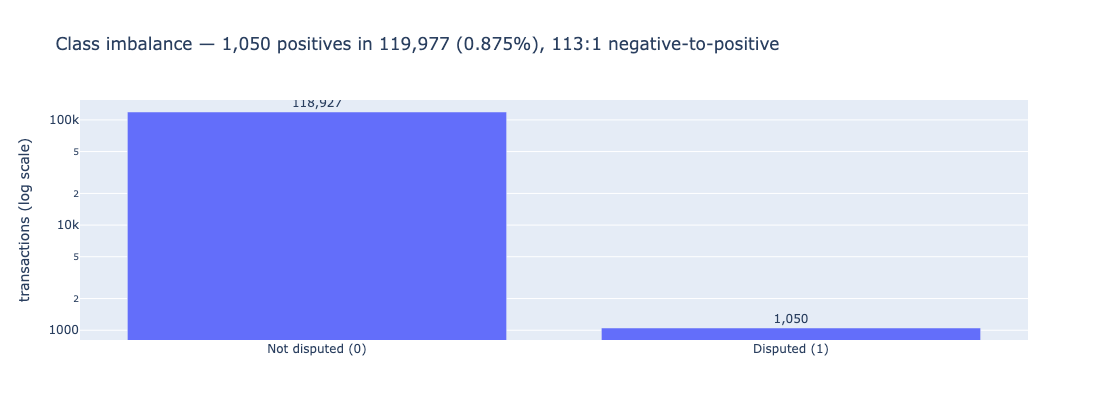

In [12]:
counts = eda["is_disputed"].value_counts().sort_index()
ratio  = counts[0] / counts[1]

fig = go.Figure(go.Bar(
    x=["Not disputed (0)", "Disputed (1)"],
    y=[counts[0], counts[1]],
    text=[f"{counts[0]:,}", f"{counts[1]:,}"],
    textposition="outside",
))
fig.update_layout(
    title=f"Class imbalance — {counts[1]:,} positives in {len(eda):,} "
          f"({counts[1]/len(eda):.3%}), {ratio:.0f}:1 negative-to-positive",
    yaxis_type="log", yaxis_title="transactions (log scale)", height=420,
)
fig.show()

## Chart 2: dispute rate over time

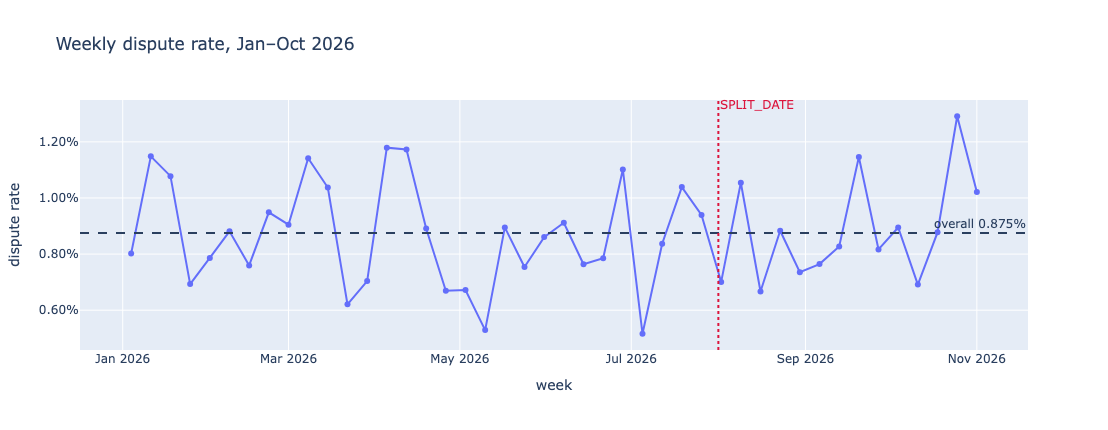

pre-split  ( 74,731 rows): 0.8604%
post-split ( 45,246 rows): 0.8995%


In [14]:
weekly = (
    eda.set_index("created_at")
       .resample("W")["is_disputed"]
       .agg(dispute_rate="mean", n="size")
       .reset_index()
)

split_ts = pd.Timestamp(SPLIT_DATE)

fig = go.Figure()
fig.add_trace(go.Scatter(x=weekly["created_at"], y=weekly["dispute_rate"],
                         mode="lines+markers", name="weekly rate"))
fig.add_hline(y=base_rate, line_dash="dash",
              annotation_text=f"overall {base_rate:.3%}")

# add_vline(x=<datetime>, annotation_text=...) raises TypeError on plotly 5.x —
# its label-placement helper sums the endpoints, and int + Timestamp is invalid.
# Drawing the shape and the annotation separately avoids that code path entirely.
fig.add_shape(type="line", x0=split_ts, x1=split_ts, y0=0, y1=1, yref="paper",
              line=dict(dash="dot", color="crimson"))
fig.add_annotation(x=split_ts, y=1.02, yref="paper", text="SPLIT_DATE",
                   showarrow=False, xanchor="left", font=dict(color="crimson"))

fig.update_layout(title="Weekly dispute rate, Jan–Oct 2026",
                  yaxis_tickformat=".2%", yaxis_title="dispute rate",
                  xaxis_title="week", height=430)
fig.show()

pre  = eda.loc[eda["created_at"] <  SPLIT_DATE, "is_disputed"]
post = eda.loc[eda["created_at"] >= SPLIT_DATE, "is_disputed"]
print(f"pre-split  ({len(pre):>7,} rows): {pre.mean():.4%}")
print(f"post-split ({len(post):>7,} rows): {post.mean():.4%}")

## Chart 3: dispute rate by segment (reusable helper)

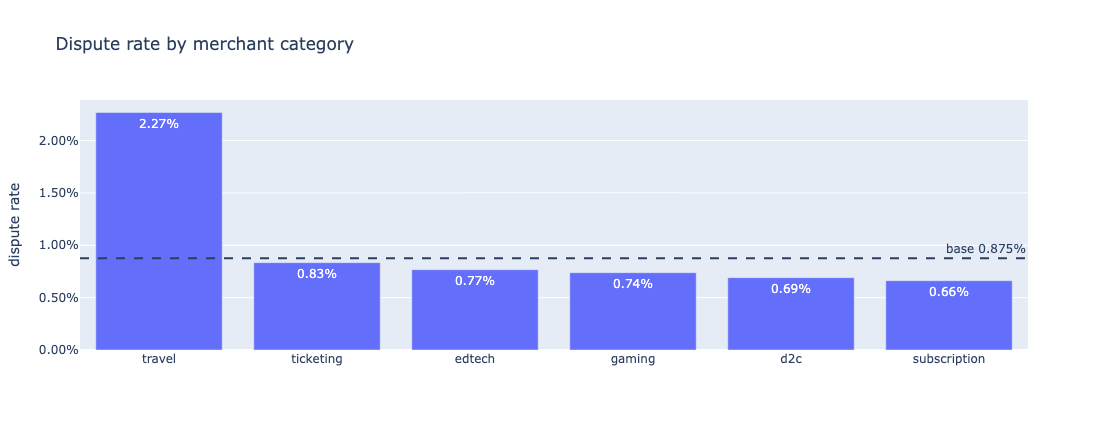

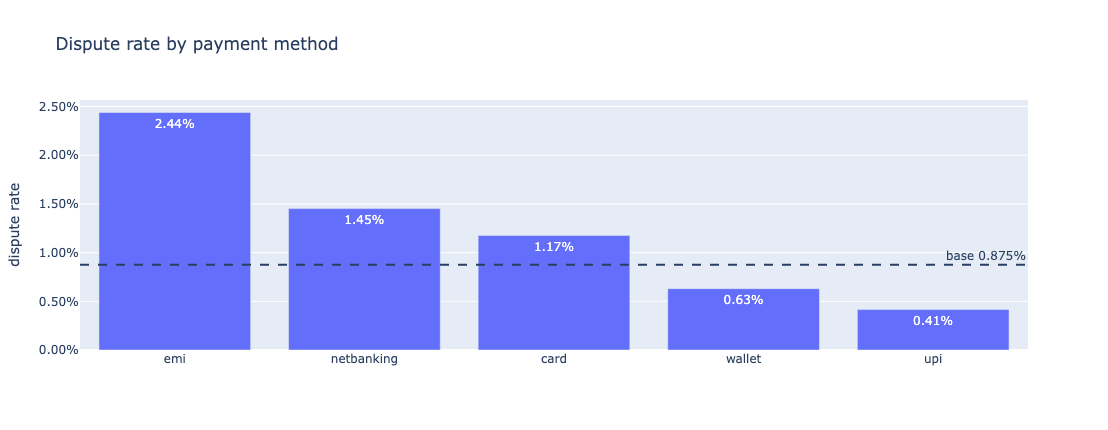

In [15]:
def segment_stats(df: pd.DataFrame, col: str, min_n: int = MIN_SEGMENT_N) -> pd.DataFrame:
    """Dispute rate, volume and average amount per value of `col`.
    Returns all segments; `below_min_n` marks the ones too small to read as signal."""
    out = (
        df.groupby(col, dropna=False)
          .agg(transaction_count=("is_disputed", "size"),
               dispute_rate=("is_disputed", "mean"),
               avg_amount=("amount", "mean"))
          .reset_index()
          .rename(columns={col: "segment_value"})
    )
    out["segment_type"] = col
    out["below_min_n"] = out["transaction_count"] < min_n
    return out.sort_values("dispute_rate", ascending=False)


def plot_segment(df: pd.DataFrame, col: str, title: str) -> go.Figure:
    s = segment_stats(df, col)
    s = s.loc[~s["below_min_n"]]
    fig = px.bar(s, x="segment_value", y="dispute_rate",
                 hover_data={"transaction_count": ":,", "avg_amount": ":.0f"},
                 text=s["dispute_rate"].map("{:.2%}".format), title=title)
    fig.add_hline(y=base_rate, line_dash="dash",
                  annotation_text=f"base {base_rate:.3%}")
    fig.update_layout(yaxis_tickformat=".2%", yaxis_title="dispute rate",
                      xaxis_title="", height=430, showlegend=False)
    return fig


plot_segment(eda, "merchant_category", "Dispute rate by merchant category").show()
plot_segment(eda, "method",            "Dispute rate by payment method").show()

## Chart 3 continued: card-only and geography segments

card transactions: 37,193  |  null bin_country within cards: 0


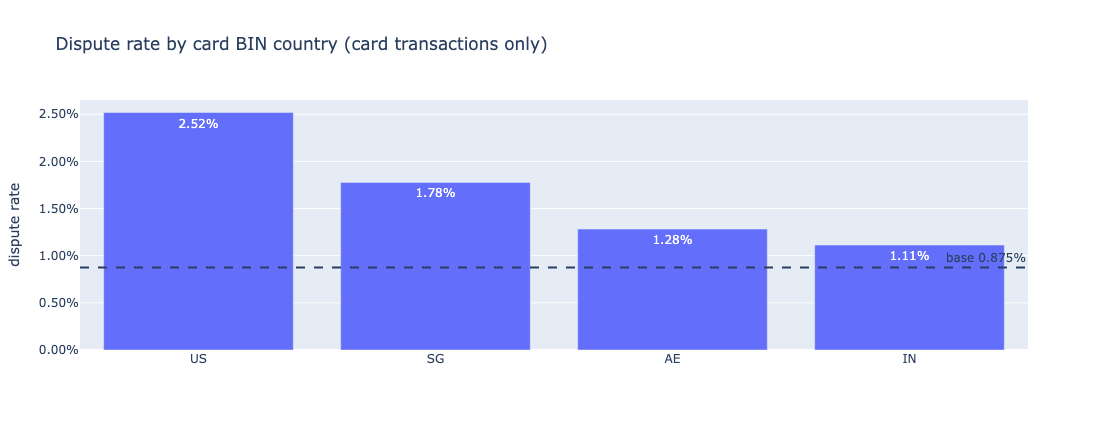

                 size  dispute_rate
is_foreign_bin                     
0               34597      0.011128
1                2596      0.020031


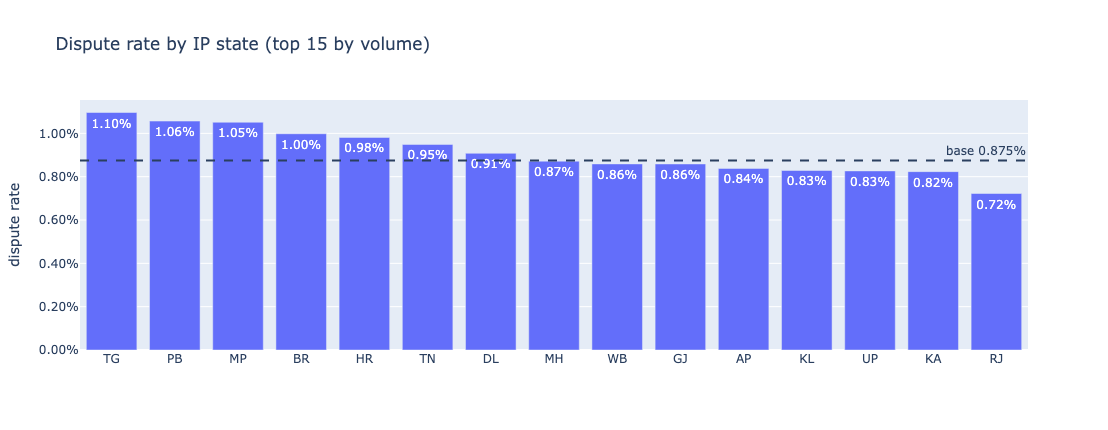


distinct ip_state values: 36 — confirms notebook 1's normalisation (spec §3.1.2) collapsed the 360 mixed-case / full-name variants; an un-normalised column would show 'MH' and 'Maharashtra' as separate bars here.


In [16]:
cards = eda.loc[eda["method"] == "card"].copy()
print(f"card transactions: {len(cards):,}  |  null bin_country within cards: "
      f"{cards['card_bin_country'].isna().sum():,}")

cards["is_foreign_bin"] = (cards["card_bin_country"] != "IN").astype(int)
plot_segment(cards, "card_bin_country",
             "Dispute rate by card BIN country (card transactions only)").show()
print(cards.groupby("is_foreign_bin")["is_disputed"]
           .agg(["size", "mean"]).rename(columns={"mean": "dispute_rate"}))

# ip_state: 36 values, long tail. Chart the top 15 by volume; MIN_SEGMENT_N filters the rest.
top_states = eda["ip_state"].value_counts().head(15).index
plot_segment(eda.loc[eda["ip_state"].isin(top_states)], "ip_state",
             "Dispute rate by IP state (top 15 by volume)").show()

print(f"\ndistinct ip_state values: {eda['ip_state'].nunique()} "
      "— confirms notebook 1's normalisation (spec §3.1.2) collapsed the "
      "360 mixed-case / full-name variants; an un-normalised column would "
      "show 'MH' and 'Maharashtra' as separate bars here.")

## Chart 4: amount distribution

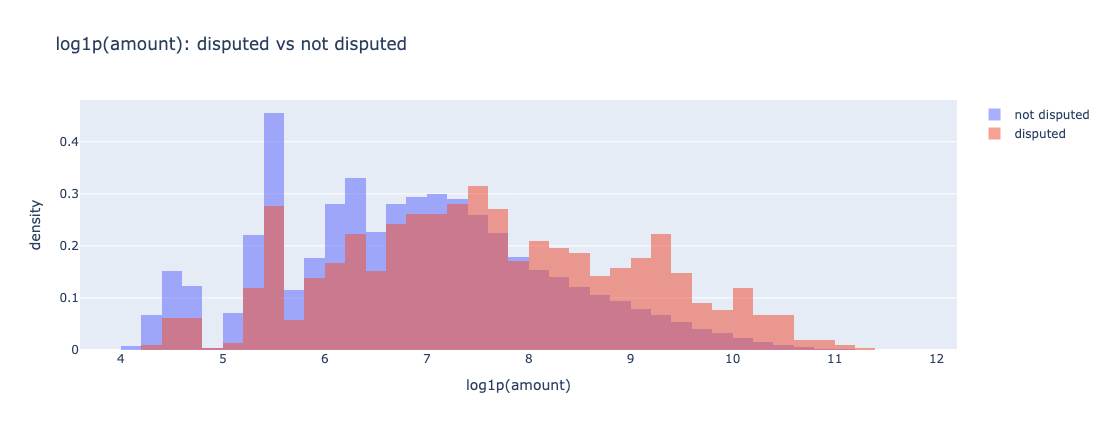

                count         mean       50%        max
is_disputed                                            
0            118927.0  2379.227385   889.780  168913.66
1              1050.0  5357.232705  1861.455   75207.35

raw amount skew     : 6.50
log1p(amount) skew  : 0.30


In [17]:
fig = go.Figure()
for label, sub in [("not disputed", eda.loc[eda.is_disputed == 0]),
                   ("disputed",     eda.loc[eda.is_disputed == 1])]:
    fig.add_trace(go.Histogram(
        x=np.log1p(sub["amount"]), name=label,
        histnorm="probability density", opacity=0.55, nbinsx=60,
    ))
fig.update_layout(barmode="overlay", title="log1p(amount): disputed vs not disputed",
                  xaxis_title="log1p(amount)", yaxis_title="density", height=430)
fig.show()

desc = eda.groupby("is_disputed")["amount"].describe()[["count", "mean", "50%", "max"]]
print(desc.to_string())
print(f"\nraw amount skew     : {eda['amount'].skew():.2f}")
print(f"log1p(amount) skew  : {np.log1p(eda['amount']).skew():.2f}")

## Two segments the dev plan doesn't list but notebooks 3 and 5 need

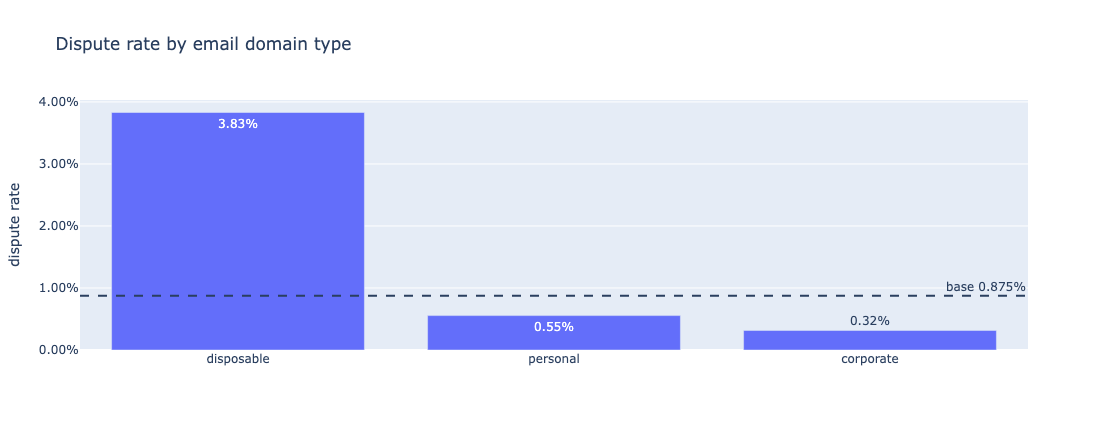

                 size  dispute_rate
phone_verified                     
False           25904      0.025788
True            94073      0.004061

transactions with a fulfilment row: 65,993 (physical-goods categories only)


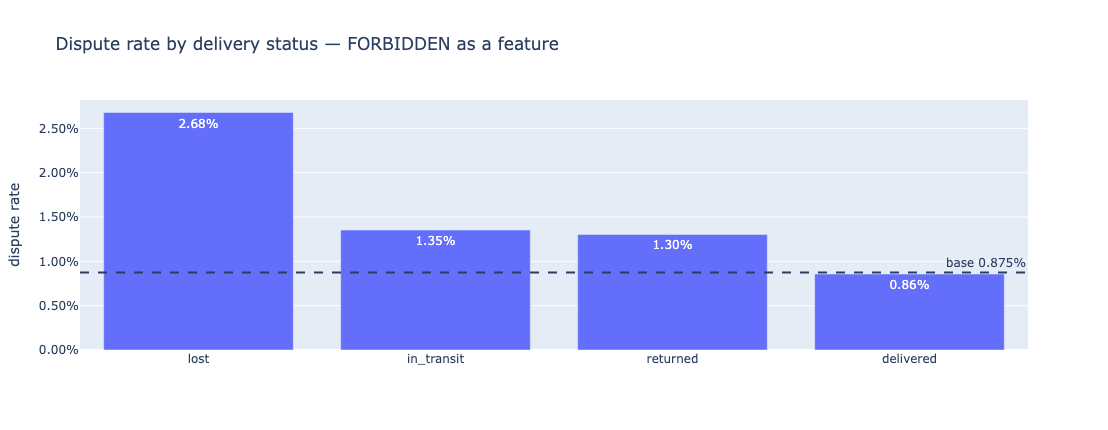

In [18]:
# (a) Customer attributes — feeds notebook 3's instant features.
cust_join = eda.merge(
    customers[["customer_id", "email_domain_type", "phone_verified",
               "account_age_days", "prior_disputes"]],
    on="customer_id", how="left", validate="many_to_one",
)
assert cust_join["email_domain_type"].isna().sum() == 0, "customer join lost rows"

plot_segment(cust_join, "email_domain_type",
             "Dispute rate by email domain type").show()
print(cust_join.groupby("phone_verified")["is_disputed"]
               .agg(["size", "mean"]).rename(columns={"mean": "dispute_rate"}))

# (b) Fulfilment — the FORBIDDEN table. Charted to justify the exclusion, not to use it.
ful_join = eda.merge(
    fulfilment[["payment_id", "delivery_status", "tracking_available",
                "address_completeness_score"]],
    on="payment_id", how="inner", validate="one_to_one",
)
print(f"\ntransactions with a fulfilment row: {len(ful_join):,} "
      f"(physical-goods categories only)")
plot_segment(ful_join, "delivery_status",
             "Dispute rate by delivery status — FORBIDDEN as a feature").show()

## Build and export 02_eda_segment_summary.csv

In [20]:
segments = pd.concat([
    segment_stats(eda,       "merchant_category"),
    segment_stats(eda,       "method"),
    segment_stats(cards,     "card_bin_country"),
    segment_stats(eda,       "ip_state"),
    segment_stats(cust_join, "email_domain_type"),
    segment_stats(ful_join,  "delivery_status"),
], ignore_index=True)

segments = segments[["segment_type", "segment_value", "dispute_rate",
                     "transaction_count", "avg_amount", "below_min_n"]]
segments["dispute_rate"] = segments["dispute_rate"].round(6)
segments["avg_amount"]   = segments["avg_amount"].round(2)

# Volume reconciliation: each segment_type sourced from `eda` must re-sum to len(eda).
for st in ["merchant_category", "method", "ip_state"]:
    tot = segments.loc[segments.segment_type == st, "transaction_count"].sum()
    assert tot == len(eda), f"{st} sums to {tot:,}, expected {len(eda):,}"

print(segments.sort_values(["segment_type", "dispute_rate"], ascending=[True, False])
              .to_string(index=False))

     segment_type segment_value  dispute_rate  transaction_count  avg_amount  below_min_n
 card_bin_country            GB      0.028169                284     1129.63         True
 card_bin_country            AU      0.026667                 75     1463.93         True
 card_bin_country            CA      0.026549                113     1115.97         True
 card_bin_country            US      0.025189                794     1280.36        False
 card_bin_country            HK      0.024096                166     1448.75         True
 card_bin_country            SG      0.017778                450     1138.97        False
 card_bin_country            AE      0.012821                546     1299.01        False
 card_bin_country            IN      0.011128              34597     1218.02        False
 card_bin_country            MY      0.000000                168     1087.49         True
  delivery_status          lost      0.026781               1979     3332.34        False
  delivery

## Export with the §1.4 round-trip assert

In [21]:
out_path = PROCESSED_DIR / "02_eda_segment_summary.csv"
segments.to_csv(out_path, index=False)

check = pd.read_csv(out_path)
assert check.shape[0] == segments.shape[0], \
    f"row count mismatch: wrote {segments.shape[0]}, read {check.shape[0]}"
assert set(check.columns) == set(segments.columns), "column mismatch after CSV round-trip"
print(f"✅ 02_eda_segment_summary.csv — {check.shape[0]} rows, {check.shape[1]} cols")

✅ 02_eda_segment_summary.csv — 64 rows, 6 cols


## Definition of done

In [22]:
checks = {
    "base rate matches notebook 1 (0.8–1.0%)": 0.008 <= base_rate <= 0.010,
    "segment summary exists and is non-empty": out_path.exists() and len(check) > 0,
    "ip_state normalised (≤ 36 distinct)":     eda["ip_state"].nunique() <= 36,
    "EDA window is 2026-01-01 → 2026-10-31":   (eda["created_at"].min().year == 2026
                                                and eda["created_at"].max().year == 2026),
    "log1p reduces amount skew":               abs(np.log1p(eda["amount"]).skew())
                                               < abs(eda["amount"].skew()),
}
for k, v in checks.items():
    print(f"{'✅' if v else '❌'} {k}")
assert all(checks.values()), "notebook 2 definition-of-done failed"

✅ base rate matches notebook 1 (0.8–1.0%)
✅ segment summary exists and is non-empty
✅ ip_state normalised (≤ 36 distinct)
✅ EDA window is 2026-01-01 → 2026-10-31
✅ log1p reduces amount skew
